# Example Script: Attention map generation


In [1]:
# Imports
%matplotlib inline
%load_ext autoreload
%autoreload 2

# import global libraries
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import captum
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    LayerGradCam,
    NoiseTunnel,
    GradientShap,
    LayerAttribution,
    Saliency,
    LRP)

# Import local libraries
from src.constants import DEVICE
from src.utils.set_random_seed import set_random_seed
from src.models.tools.get_classification_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.config_presets.tools.load_config import load_config
from src.dataset.load_dataset import load_dataset
from src.dataset.get_dataloader import make_dataloader   
from src.dataset.get_transforms import get_transforms
from src.visualization.attribution.GradCamPlusPlus import GradCamPlusPlus

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)


### Loading a model and the test dataset

In [2]:
# define the directory of the experiment trial
trial_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet10"
Kfold_folder = r"KFold1"
Kfold_folder_dir = os.path.join(trial_dir, Kfold_folder)
filename_model_weights = "DlModel_Weights.pth"
filename_config = "DlModel_Config.yaml"

# select if the config file is loaded with path or global
config = load_config(os.path.join(trial_dir, Kfold_folder,"DlModel_Config.yaml")) #get_config('DETOXLung_config')

# Disable randomness
set_random_seed(config['general']['seed'])


C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet10\KFold1\DlModel_Config.yaml


In [3]:
# load data
df_train_val, df_test = load_dataset(config)
train_transforms, val_transforms = get_transforms(config)
test_loader, metadata = make_dataloader(config, df_test, val_transforms, validation_mode=True)


pathModelWeigths = os.path.join(Kfold_folder_dir, filename_model_weights)
model = get_classification_model(config, metadata, False)
model.load_state_dict(torch.load(pathModelWeigths))
print("Successfully loaded model and datasets")

Removed patients (no image data) = 0
Train/Val dataset 872 (80.0%), Test dataset 218 (20.0%)


c:\Users\S.P.M. de Vette\.conda\envs\HNC_310\lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Successfully loaded model and datasets


## Wrapping the model in the Captum package's input wrapper

This allows the model to accept multiple inputs (i.e. the clinical features, and not just one array of image features)

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# wrap the model in the ModelInputWrapper, so that we can give it the clinical features (without captum getting mad)
model = ModelInputWrapper(model)

model.to(DEVICE)     # send the model to the GPU

# put the model into evaluation mode ! this saves some GPU space
model.eval()

ModelInputWrapper(
  (module): MultiTox_Classifier(
    (encoder): ResNet_LReLU(
      (conv1): Conv3d(3, 64, kernel_size=(5, 5, 5), stride=(2, 2, 2), padding=(2, 2, 2), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1)
      (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (backbone): ModuleList(
        (0): Sequential(
          (0): BasicBlock(
            (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): LeakyReLU(negative_slope=0.1)
            (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): Sequential

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)


# Applying the attribution map method



## First, you have to pick a layer to apply an attribution method to
The next block of code prints out all of your possible choices. Usually you either pick one of the convolutional layers (module name ends with something like 'conv', e.g. `model.module.encoder.backbone.block1.0.conv1`) or you can pick one of the blocks (e.g. `encoder.backbone.block3`). The next block of code can be used to help show what the result is of picking different layers (for one model/fold, on one patient)

In [5]:
for name, module in model.module.named_modules():
    print(name)


encoder
encoder.conv1
encoder.bn1
encoder.act
encoder.maxpool
encoder.backbone
encoder.backbone.block0
encoder.backbone.block0.0
encoder.backbone.block0.0.conv1
encoder.backbone.block0.0.bn1
encoder.backbone.block0.0.act
encoder.backbone.block0.0.conv2
encoder.backbone.block0.0.bn2
encoder.backbone.block1
encoder.backbone.block1.0
encoder.backbone.block1.0.conv1
encoder.backbone.block1.0.bn1
encoder.backbone.block1.0.act
encoder.backbone.block1.0.conv2
encoder.backbone.block1.0.bn2
encoder.backbone.block1.0.downsample
encoder.backbone.block1.0.downsample.0
encoder.backbone.block1.0.downsample.1
encoder.backbone.block2
encoder.backbone.block2.0
encoder.backbone.block2.0.conv1
encoder.backbone.block2.0.bn1
encoder.backbone.block2.0.act
encoder.backbone.block2.0.conv2
encoder.backbone.block2.0.bn2
encoder.backbone.block2.0.downsample
encoder.backbone.block2.0.downsample.0
encoder.backbone.block2.0.downsample.1
encoder.backbone.block3
encoder.backbone.block3.0
encoder.backbone.block3.0.co

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  2%|▏         | 4/218 [00:00<00:34,  6.18it/s]


GradCam conv1
GradCam block0
GradCam block1
GradCam block2
GradCam block3


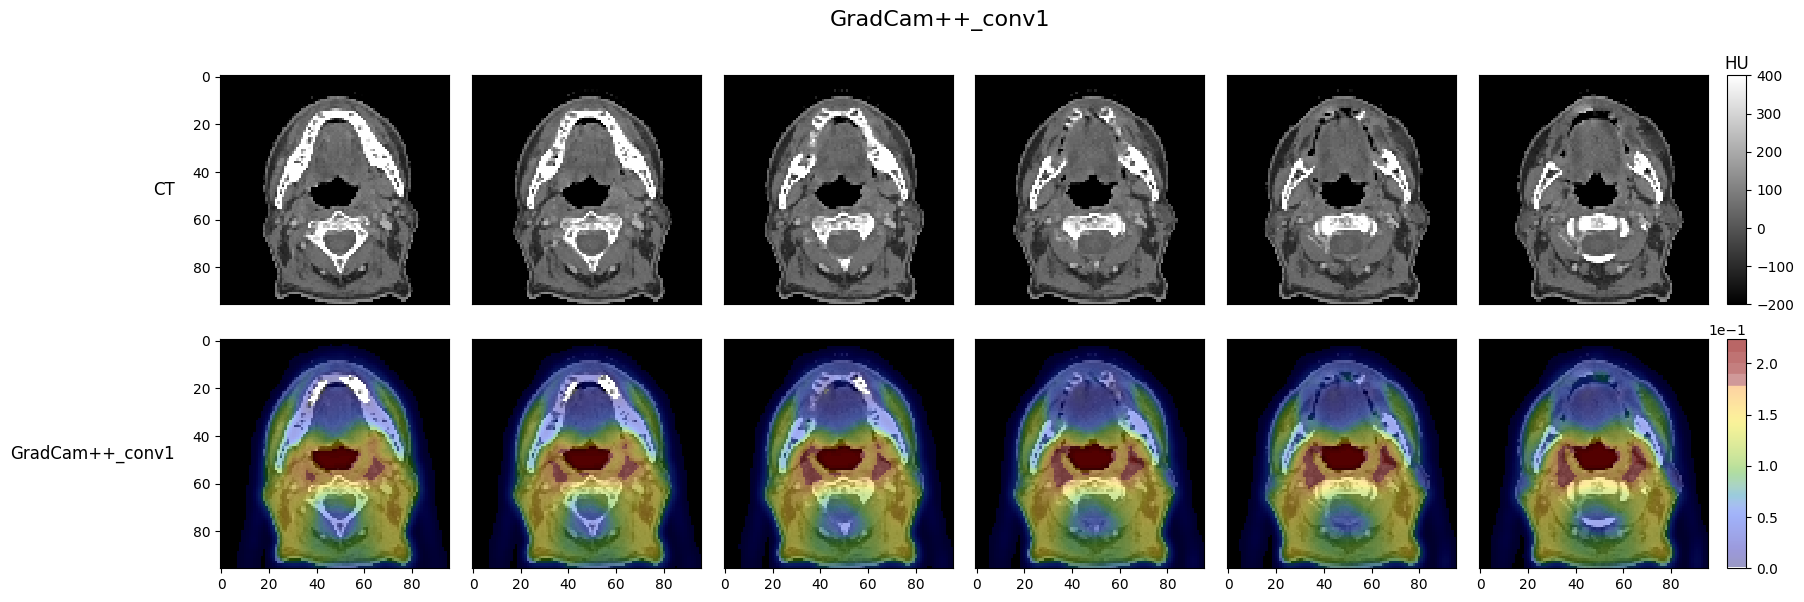

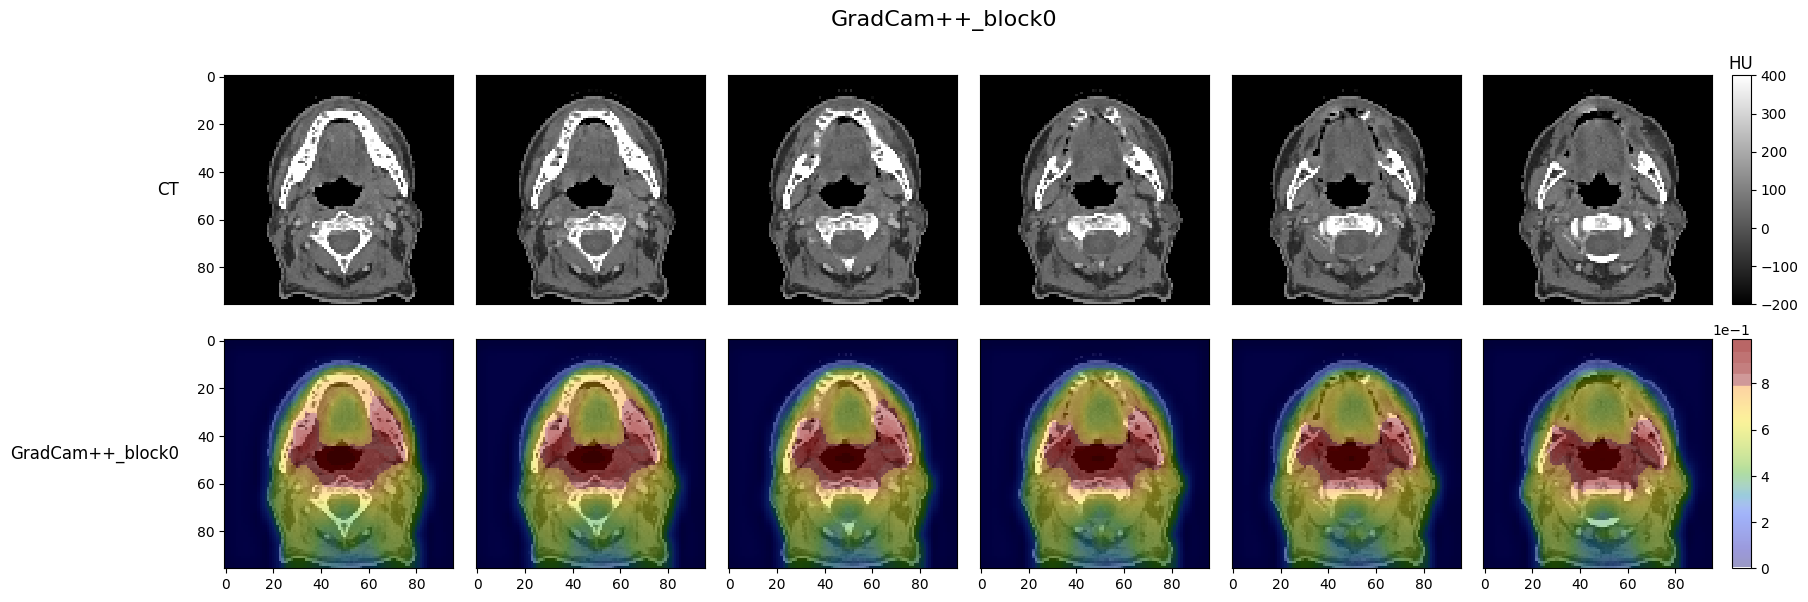

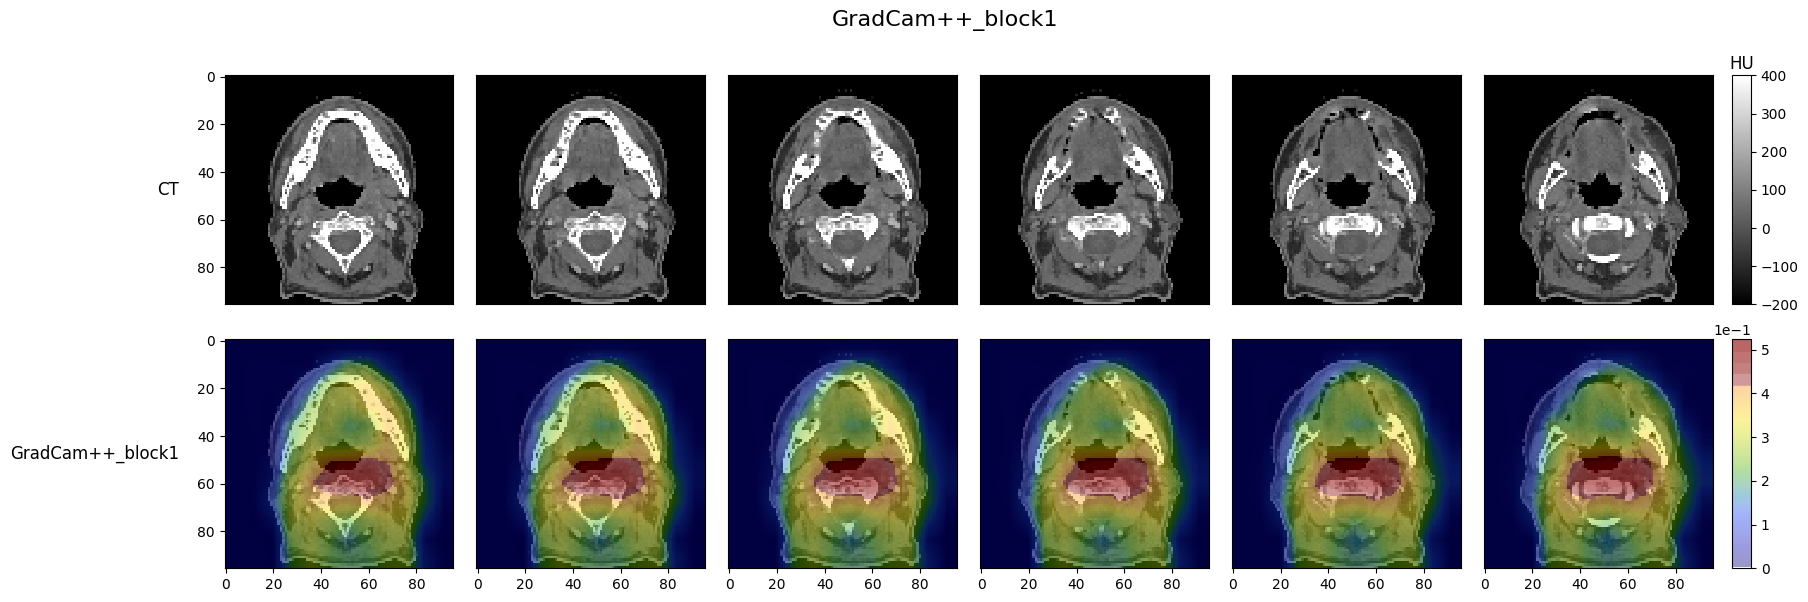

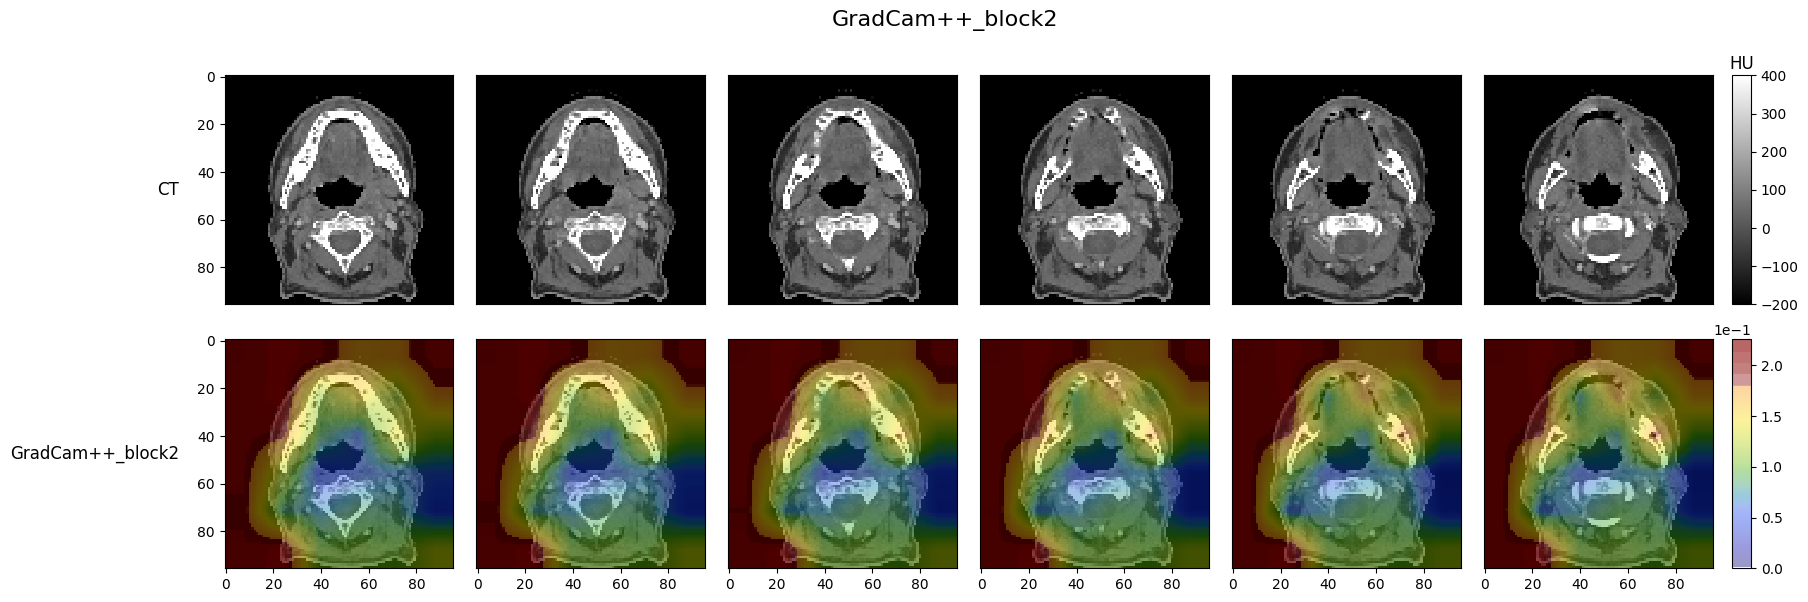

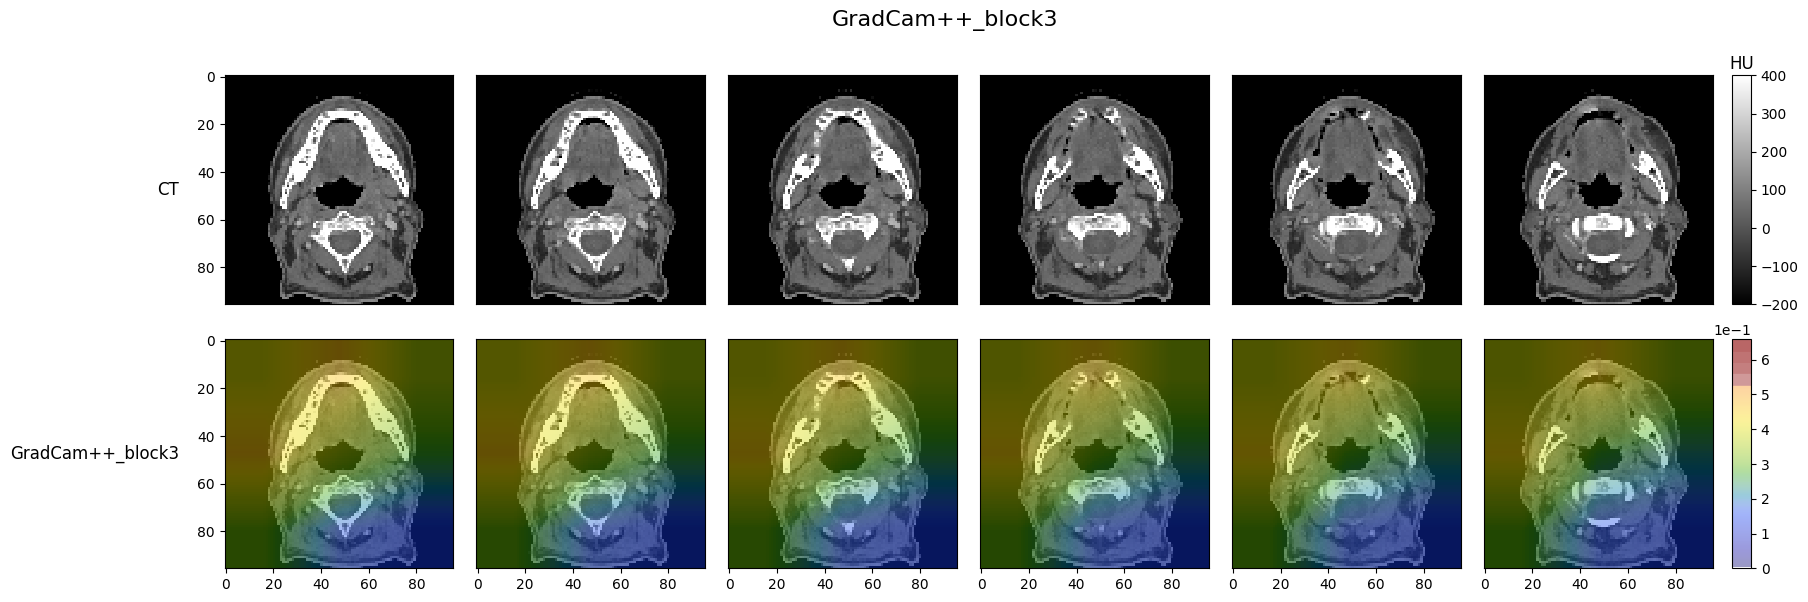

In [6]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

#####################################
# Define stuff within here:

"""
Some settings:
"""
output_index = 0 # the index of the output class/toxicity that we want to calculate the attention map for (for single-toxicity models, this should be 0)
plusplus = True  # if we want to use GradCam++ instead of GradCam
attribute_to_layer_input = False
relu_attributions = False
interpolation_method = 'trilinear' # method to interpolate the attribution map back to the input image dimensions (normal GradCam uses 'trilinear', but you can also try 'nearest' or 'area')

slices = [67,68,69,70,71,72]               # NOTE: define which slices you want to plot here (might differ per patient, depending on what you want to see)

"""
Pick which layers you want to try out (and plot the attention maps for a patient)
key : module, where key = some string, and module = the layer of the model
"""
modules_dict = {
        "conv1": model.module.encoder.conv1,
        "block0": model.module.encoder.backbone.block0[0],
        "block1": model.module.encoder.backbone.block1[0],
        "block2": model.module.encoder.backbone.block2[0],
        "block3": model.module.encoder.backbone.block3[0],
    }



######################################
# Now the actual code starts


attr_maps = []  # a list to store the attention maps for each layer in (they each get plotted later)

for data in tqdm(test_loader):
    data
    # Load data, send it to the GPU
    inputs, features, label_list = (
        data['input'].to(DEVICE),
        data['features'].to(DEVICE),
        data['label_list'].to(DEVICE),
        )
    # also pass the clinical features to the model
    additional_forward_args = (features, True)

    # let's try to find a patient that has a toxicity, just for a more interesting example
    if label_list.item() == 0:
        continue
    
    
    for name, model_layer in modules_dict.items():
        print("GradCam", name)

        attr = GradCamPlusPlus(model, model_layer)
        image_attention = attr.attribute(inputs, target=output_index, additional_forward_args= additional_forward_args, attribute_to_layer_input=attribute_to_layer_input, 
                                         relu_attributions=relu_attributions, plusplus=plusplus)

        # bring the attribution map back to the dimenions of the input images
        upsampled_attribution = LayerAttribution.interpolate(image_attention, inputs.shape[2:], interpolate_mode=interpolation_method)   

        attr_maps.append({'method': 'GradCam++_'+name, 'attention': upsampled_attribution[0][0].squeeze().cpu().detach().numpy()})   

    torch.cuda.empty_cache()

    # break after the first patient !!!!
    break



# plot the attention maps for each layer

from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

CT = inputs[0][0].squeeze().cpu().detach().numpy() * 600 - 200  # NOTE: un-normalize the CT image (head and neck dataset)

plotting_dicts = []

plot_CT_dict = {
    "Label": "CT",
    "CT": CT,
}

plotting_dicts.append(plot_CT_dict)

for attr_dict in attr_maps:
    method_dict = {
        "Label": attr_dict['method'],
        'CT': CT,
        "Attention" : attr_dict['attention']
    }
    plotting_dicts.append(method_dict)
   
    #slices = [71,72,73,74,75,76,77]
    fig, axes = plot_slices(row_dicts=[plot_CT_dict] + [method_dict], slice_indexes=slices, title=attr_dict['method'])
    plt.show()


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)


# Plot all of the patients in the test set

After defining some of the settings yourself, this code generates attention maps for each fold, on all of the test patients.

Note that you have to define the model layer to use for the attention map about halfway down the main block of code (it is marked with a comment)

In [7]:
# directory to the trial folder
trial_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet10"
filename_model_weights = "DlModel_Weights.pth"
filename_config = "DlModel_Config.yaml"

# where to save the attention maps (and their plots)
output_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\XeroM06_att_maps"
attr_maps_foldername = 'attention'
attr_plots_foldername = 'attention_plots'

all_Kfold_folders = [f for f in os.listdir(trial_dir) if os.path.isdir(os.path.join(trial_dir, f))]



C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet10\KFold1
C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet10\KFold1\DlModel_Config.yaml


 25%|██▍       | 54/218 [00:26<01:19,  2.07it/s]


KeyboardInterrupt: 

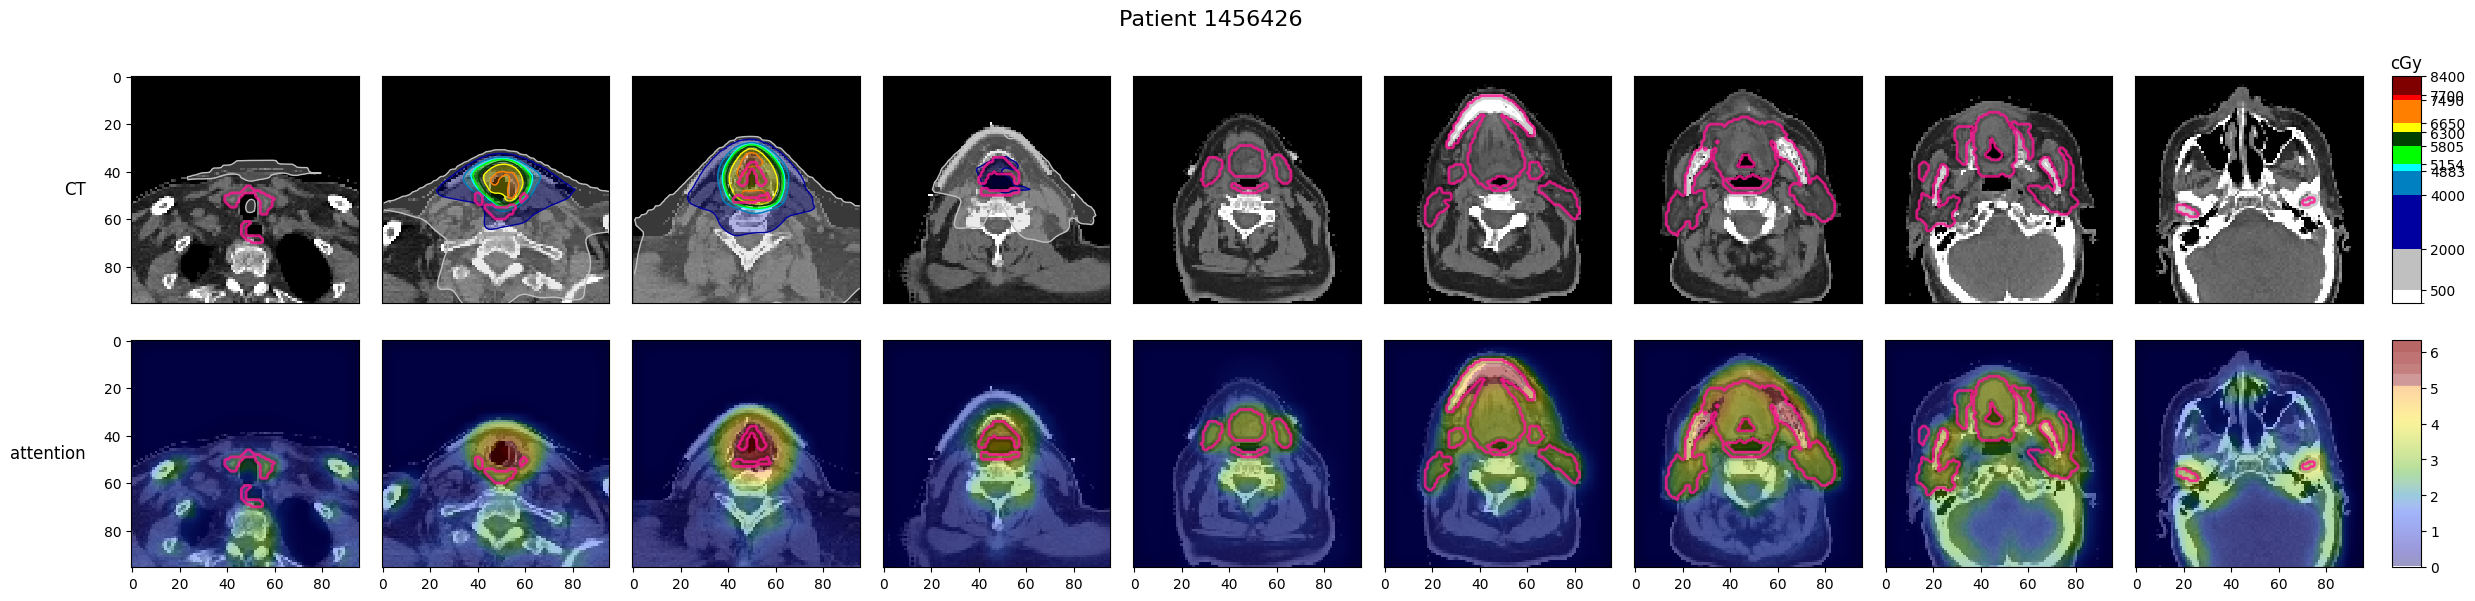

In [9]:

"""
Some settings:
"""
output_index = 0 # the index of the output class/toxicity that we want to calculate the attention map for (for single-toxicity models, this should be 0)
plusplus = True  # if we want to use GradCam++ instead of GradCam
attribute_to_layer_input = False
relu_attributions = False
interpolation_method = 'trilinear' # method to interpolate the attribution map back to the input image dimensions (normal GradCam uses 'trilinear', but you can also try 'nearest' or 'area')

# for plotting the attention maps
slices = [10, 20, 30, 40, 50, 60, 70, 80, 90] 



for Kfold_folder in all_Kfold_folders:
    # output dirs
    output_arrays_dir = os.path.join(output_dir, Kfold_folder, attr_maps_foldername)
    os.makedirs(output_arrays_dir, exist_ok=True)
    output_plots_dir = os.path.join(output_dir, Kfold_folder, attr_plots_foldername)
    os.makedirs(output_plots_dir, exist_ok=True)

    fold_dir = os.path.join(trial_dir, Kfold_folder)
    print(fold_dir)
    # load the config of this fold
    fold_config = load_config(os.path.join(fold_dir, filename_config))
    # load the model of this fold
    pathModelWeigths = os.path.join(fold_dir, filename_model_weights)
    model = get_classification_model(config, metadata, False)
    model.load_state_dict(torch.load(pathModelWeigths))

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ModelInputWrapper(model)
    model.to(DEVICE)  
    model.eval()

    """ 
    Pick one layer in the model  ###################################################################################################
    """
    model_layer = model.module.encoder.backbone.block0[0]                                      # NOTE: define the model layer here !!
    """
    ################################################################################################################################
    """


    for data in tqdm(test_loader):
        # Load data, send it to the GPU
        inputs, features, label_list = (
            data['input'].to(DEVICE),
            data['features'].to(DEVICE),
            data['label_list'].to(DEVICE),
            )
        patient_id = data['patient_id'][0]
        # also pass the clinical features to the model
        additional_forward_args = (features, True)
        
        attr = GradCamPlusPlus(model, model_layer)
        image_attention = attr.attribute(inputs, target=output_index, additional_forward_args= additional_forward_args, attribute_to_layer_input=attribute_to_layer_input, 
                                            relu_attributions=relu_attributions, plusplus=plusplus)

        # bring the attribution map back to the dimenions of the input images
        upsampled_attribution = LayerAttribution.interpolate(image_attention, inputs.shape[2:], interpolate_mode=interpolation_method)   

        # get the attention map as a numpy array
        upsampled_attribution = upsampled_attribution[0][0].squeeze().cpu().detach().numpy()

        attr_maps.append({'method': 'GradCam++_'+name, 'attention': upsampled_attribution})   

        torch.cuda.empty_cache()


        # make and save a plot
        CT = inputs[0][0].squeeze().cpu().detach().numpy() * 600 - 200  # un-normalize the CT image
        RTDOSE = inputs[0][1].squeeze().cpu().detach().numpy() # * 8000
        RTSTRUCT = inputs[0][2].squeeze().cpu().detach().numpy()

        plotting_dicts = [{
                "Label": "CT",
                "CT": CT,
                "RTDOSE"  : RTDOSE,
                "RTSTRUCT" : RTSTRUCT,
            }, {
                "Label": "attention",
                'CT': CT,
                "Attention" : upsampled_attribution,
                "RTSTRUCT" : RTSTRUCT,
            }
        ]

        fig, axes = plot_slices(row_dicts=plotting_dicts, slice_indexes=slices, title=f"Patient {patient_id}", plotting_axis="axial")  # NOTE: you can change the plotting axis here if you want
        #plt.show()

        fig.savefig(os.path.join(output_plots_dir, f"{patient_id}.png"))
        plt.close(fig)

        # save the attention map as a numpy array
        np.save(os.path.join(output_arrays_dir, f"{patient_id}.npy"), upsampled_attribution)

    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  0%|          | 0/218 [00:00<?, ?it/s]

GradCam


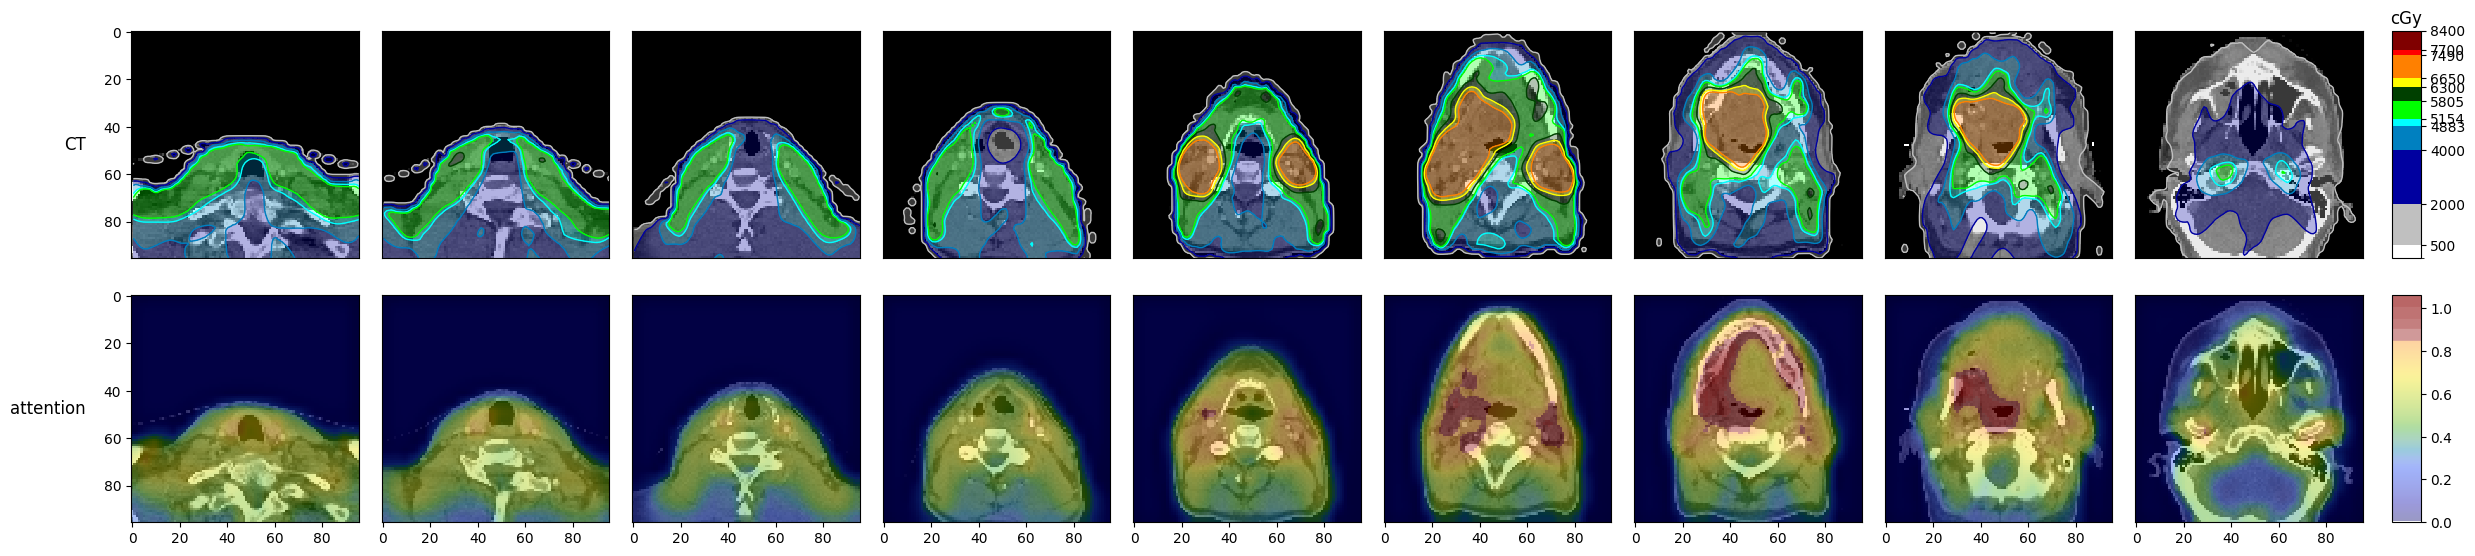

  0%|          | 0/218 [00:00<?, ?it/s]


In [46]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

